In [1]:
!pip install numpy pandas matplotlib scikit-learn umap-learn pacmap trimap imbalanced-learn seaborn 

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Dimensionality reduction algorithms
from sklearn.manifold import TSNE
import umap
import trimap
import pacmap

# Scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Dataset loading
from imblearn.datasets import fetch_datasets

# For mammoth subsampling
np.random.seed(42)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Dimensionality Reduction on ozone_level dataset

In [3]:
# Load ozone_level dataset — Variant 16
ozone = fetch_datasets(filter_data=('ozone_level',))['ozone_level']


X = ozone.data
y = ozone.target

print(f"Dataset: ozone_level")
print(f"Shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Class distribution: {np.bincount(y.astype(int) + 1)}")
print(f"Minority class count: {sum(y == -1)}")
print(f"Majority class count: {sum(y == 1)}")

Dataset: ozone_level
Shape: (2536, 72)
Features: 72
Samples: 2536
Class distribution: [2463    0   73]
Minority class count: 2463
Majority class count: 73


## Scaling Variants

In [4]:
scalers = {
    'MinMax': MinMaxScaler(),
    'Standard': StandardScaler(),
    'Robust': RobustScaler()
}

X_scaled = {}
for name, scaler in scalers.items():
    X_scaled[name] = scaler.fit_transform(X)
    print(f"{name} scaling complete — shape: {X_scaled[name].shape}")

# Quick statistics to show the differences
print("\n--- Scaling comparison (first 3 features) ---")
for name, X_s in X_scaled.items():
    print(f"\n{name}:")
    print(f"  Mean: {X_s[:, :3].mean(axis=0).round(3)}")
    print(f"  Std:  {X_s[:, :3].std(axis=0).round(3)}")
    print(f"  Min:  {X_s[:, :3].min(axis=0).round(3)}")
    print(f"  Max:  {X_s[:, :3].max(axis=0).round(3)}")

MinMax scaling complete — shape: (2536, 72)
Standard scaling complete — shape: (2536, 72)
Robust scaling complete — shape: (2536, 72)

--- Scaling comparison (first 3 features) ---

MinMax:
  Mean: [0.244 0.23  0.247]
  Std:  [0.193 0.19  0.204]
  Min:  [0. 0. 0.]
  Max:  [1. 1. 1.]

Standard:
  Mean: [-0. -0.  0.]
  Std:  [1. 1. 1.]
  Min:  [-1.267 -1.207 -1.207]
  Max:  [3.919 4.043 3.688]

Robust:
  Mean: [0.228 0.195 0.237]
  Std:  [0.761 0.772 0.763]
  Min:  [-0.737 -0.737 -0.684]
  Max:  [3.211 3.316 3.053]


### Define Parameter Combinations

In [5]:
# ============================================================
# PARAMETER COMBINATIONS FOR EACH ALGORITHM
# Default + 6 variants = 7 total per algorithm
# ============================================================

tsne_params = [
    # (label, perplexity, early_exaggeration, learning_rate, n_iter)
    ('Default', 30, 12, 'auto', 1000),
    ('P5', 5, 12, 'auto', 1000),
    ('P15', 15, 12, 'auto', 1000),
    ('P50', 50, 12, 'auto', 1000),
    ('P30-EE24-LR500-N2000', 30, 24, 500, 2000),
    ('P100', 100, 12, 'auto', 1000),
    ('P15-EE8-LR200-N500', 15, 8, 200, 500),
]

umap_params = [
    # (label, n_neighbors, min_dist, metric)
    ('Default', 15, 0.1, 'euclidean'),
    ('N5', 5, 0.1, 'euclidean'),
    ('N30', 30, 0.1, 'euclidean'),
    ('N50-MD0', 50, 0.0, 'euclidean'),
    ('N15-MD0.5-MAN', 15, 0.5, 'manhattan'),
    ('N100-MD0.99-COS', 100, 0.99, 'cosine'),
    ('N10-MD0.01', 10, 0.01, 'euclidean'),
]

trimap_params = [
    # (label, n_inliers, n_outliers, n_random, n_iters)
    ('Default', 10, 5, 5, 400),
    ('IN5-OUT3-RND3', 5, 3, 3, 400),
    ('IN20-OUT10-RND10', 20, 10, 10, 400),
    ('IN50-OUT20-RND20-N800', 50, 20, 20, 800),
    ('IN10-OUT10-RND5-N200', 10, 10, 5, 200),
    ('IN20-OUT5-RND20-N800', 20, 5, 20, 800),
    ('IN15-OUT8-RND8', 15, 8, 8, 400),
]

pacmap_params = [
    # (label, n_neighbors, MN_ratio, FP_ratio)
    ('Default', 10, 0.5, 2.0),
    ('N5', 5, 0.5, 2.0),
    ('N20', 20, 0.5, 2.0),
    ('N50-MN1.0', 50, 1.0, 2.0),
    ('N10-MN0.1-FP5.0', 10, 0.1, 5.0),
    ('N10-MN2.0-FP0.5', 10, 2.0, 0.5),
    ('N15-MN0.8-FP1.5', 15, 0.8, 1.5),
]

print("Parameter combinations defined:")
print(f"  t-SNE:   {len(tsne_params)} variants")
print(f"  UMAP:    {len(umap_params)} variants")
print(f"  TriMap:  {len(trimap_params)} variants")
print(f"  PaCMAP:  {len(pacmap_params)} variants")
print(f"  Total per scaler: {len(tsne_params) + len(umap_params) + len(trimap_params) + len(pacmap_params)}")

Parameter combinations defined:
  t-SNE:   7 variants
  UMAP:    7 variants
  TriMap:  7 variants
  PaCMAP:  7 variants
  Total per scaler: 28


### Run All Embeddings (Ozone Level)

In [6]:
# Store results
results = {}

# Helper to run an algorithm with timing
def run_embedding(algo_name, X_input, params_dict):
    start = time.time()
    try:
        if algo_name == 't-SNE':
            label, perp, ee, lr, n_iter = params_dict
            model = TSNE(n_components=2, perplexity=perp,
                         early_exaggeration=ee, learning_rate=lr,
                         max_iter=n_iter, random_state=42, init='pca')
            X_2d = model.fit_transform(X_input)
        elif algo_name == 'UMAP':
            label, nn, md, metric = params_dict
            model = umap.UMAP(n_components=2, n_neighbors=nn,
                              min_dist=md, metric=metric,
                              random_state=42)
            X_2d = model.fit_transform(X_input)
        elif algo_name == 'TriMap':
            label, ni, no, nr, nit = params_dict
            model = trimap.TRIMAP(n_inliers=ni, n_outliers=no,
                                  n_random=nr, n_iters=nit,
                                  verbose=False)
            X_2d = model.fit_transform(X_input)
        elif algo_name == 'PaCMAP':
            label, nn, mn, fp = params_dict
            model = pacmap.PaCMAP(n_components=2, n_neighbors=nn,
                                  MN_ratio=mn, FP_ratio=fp,
                                  random_state=42)
            X_2d = model.fit_transform(X_input, init='pca')
        elapsed = time.time() - start
        return X_2d, elapsed, None
    except Exception as e:
        elapsed = time.time() - start
        return None, elapsed, str(e)

# Run all combinations
algo_configs = [
    ('t-SNE', tsne_params),
    ('UMAP', umap_params),
    ('TriMap', trimap_params),
    ('PaCMAP', pacmap_params),
]

for scaler_name, X_s in X_scaled.items():
    print(f"\n{'='*60}")
    print(f"SCALER: {scaler_name}")
    print(f"{'='*60}")
    
    for algo_name, params_list in algo_configs:
        for params in params_list:
            label = params[0]
            key = f"{scaler_name}_{algo_name}_{label}"
            
            X_2d, elapsed, error = run_embedding(algo_name, X_s, params)
            
            if error:
                print(f"  ✗ {algo_name} [{label}]: FAILED — {error}")
                results[key] = {'embedding': None, 'time': elapsed, 'error': error}
            else:
                print(f"  ✓ {algo_name} [{label}]: {elapsed:.2f}s")
                results[key] = {'embedding': X_2d, 'time': elapsed, 'error': None}

print(f"\n{'='*60}")
print(f"Total embeddings computed: {sum(1 for v in results.values() if v['embedding'] is not None)}")
print(f"Total failures: {sum(1 for v in results.values() if v['error'] is not None)}")


SCALER: MinMax
  ✓ t-SNE [Default]: 7.79s
  ✓ t-SNE [P5]: 4.98s
  ✓ t-SNE [P15]: 5.74s
  ✓ t-SNE [P50]: 7.57s
  ✓ t-SNE [P30-EE24-LR500-N2000]: 12.87s
  ✓ t-SNE [P100]: 9.93s
  ✓ t-SNE [P15-EE8-LR200-N500]: 3.33s
  ✓ UMAP [Default]: 28.12s
  ✓ UMAP [N5]: 10.27s
  ✓ UMAP [N30]: 14.10s
  ✓ UMAP [N50-MD0]: 14.16s
  ✓ UMAP [N15-MD0.5-MAN]: 13.88s
  ✓ UMAP [N100-MD0.99-COS]: 18.34s
  ✓ UMAP [N10-MD0.01]: 11.52s
  ✓ TriMap [Default]: 20.19s
  ✓ TriMap [IN5-OUT3-RND3]: 2.36s
  ✓ TriMap [IN20-OUT10-RND10]: 10.92s
  ✓ TriMap [IN50-OUT20-RND20-N800]: 86.33s
  ✓ TriMap [IN10-OUT10-RND5-N200]: 3.95s
  ✓ TriMap [IN20-OUT5-RND20-N800]: 12.91s


  ✓ TriMap [IN15-OUT8-RND8]: 7.48s


  ✓ PaCMAP [Default]: 2.77s


  ✓ PaCMAP [N5]: 1.74s


  ✓ PaCMAP [N20]: 3.60s


...

  ✓ PaCMAP [N5]: 2.25s


  ✓ PaCMAP [N20]: 4.55s


  ✓ PaCMAP [N50-MN1.0]: 8.46s


  ✓ PaCMAP [N10-MN0.1-FP5.0]: 4.48s


  ✓ PaCMAP [N10-MN2.0-FP0.5]: 2.66s
  ✓ PaCMAP [N15-MN0.8-FP1.5]: 3.35s

Total embeddings computed: 84
Total failures: 0


### Visualize Ozone Level - Grid by Scaler and Algorithm

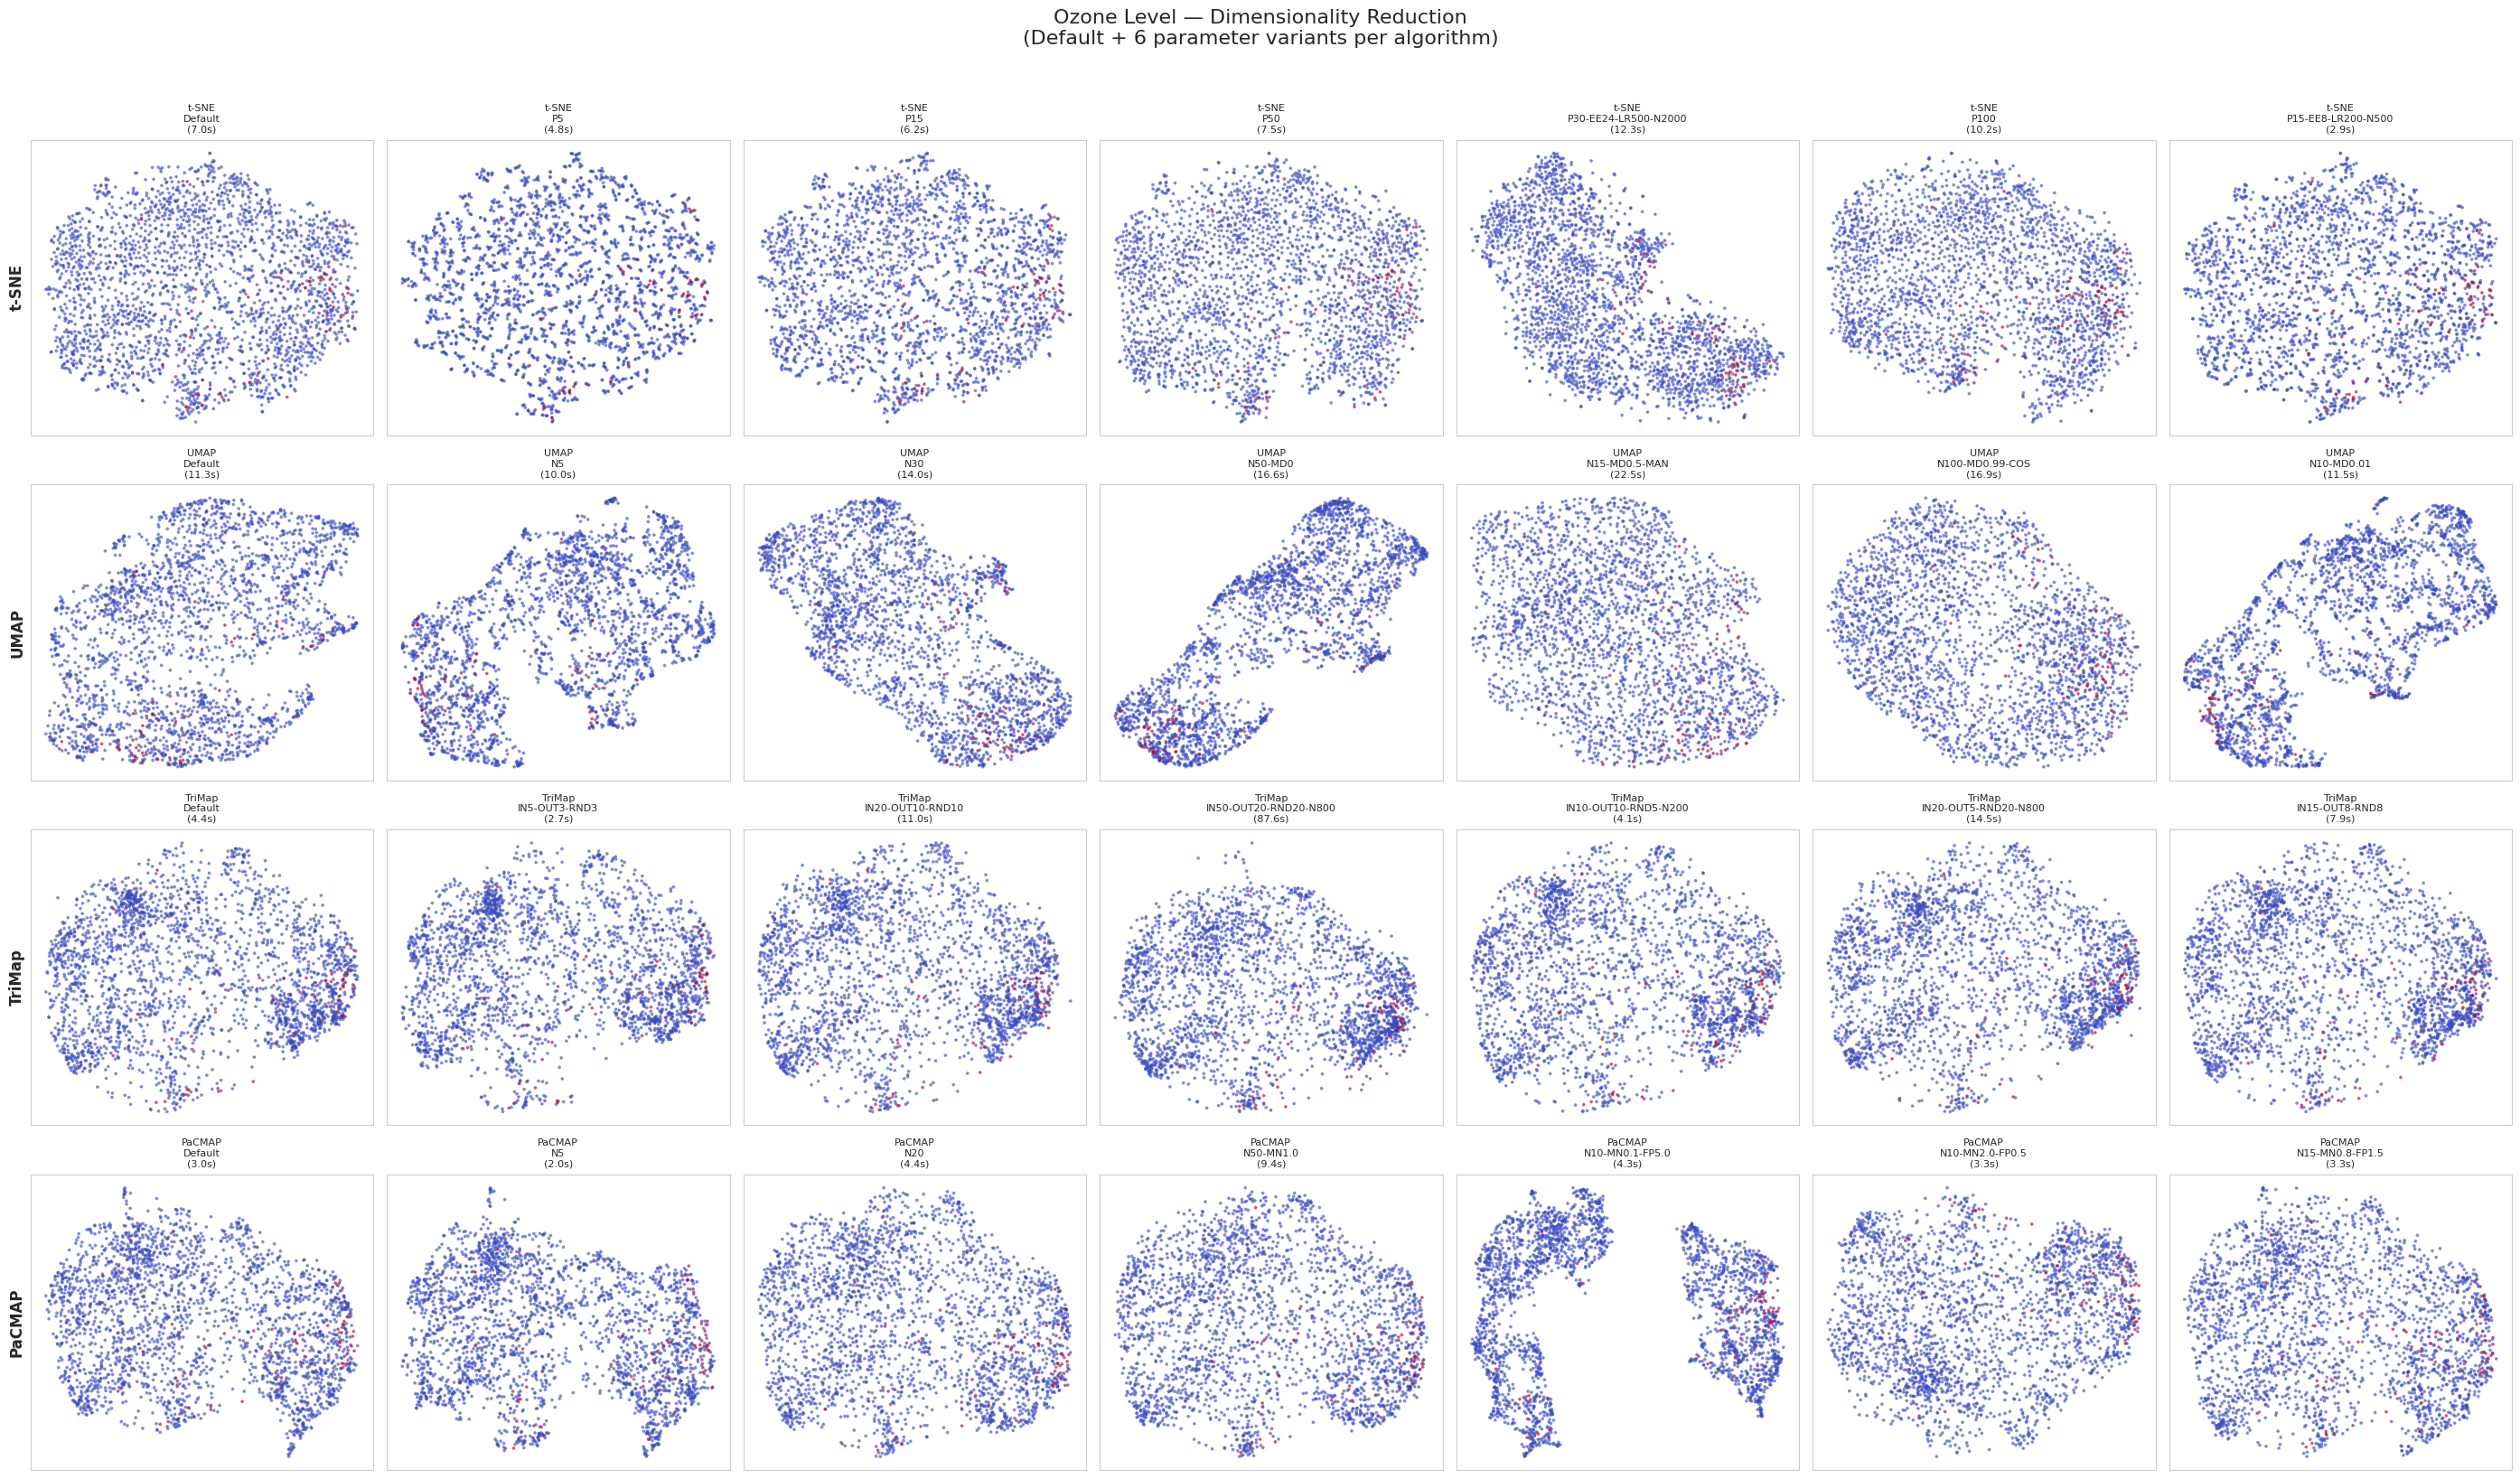

In [7]:
# Create a comprehensive grid visualization
# Rows = 4 algorithms, Columns = 7 parameter variants
# One figure per scaler

fig, axes = plt.subplots(4, 7, figsize=(28, 16))
fig.suptitle('Ozone Level — Dimensionality Reduction\n(Default + 6 parameter variants per algorithm)',
             fontsize=16, y=1.02)

for row, (algo_name, params_list) in enumerate(algo_configs):
    for col, params in enumerate(params_list):
        label = params[0]
        key = f"Standard_{algo_name}_{label}"  # Change scaler here to view different scalers
        
        ax = axes[row, col]
        res = results.get(key)
        
        if res and res['embedding'] is not None:
            X_2d = res['embedding']
            scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                                 c=y, cmap='coolwarm', s=3, alpha=0.5)
            ax.set_title(f'{algo_name}\n{label}\n({res["time"]:.1f}s)',
                        fontsize=8)
        else:
            ax.set_title(f'{algo_name}\n{label}\n(FAILED)', fontsize=8)
            ax.text(0.5, 0.5, 'Error', ha='center', va='center',
                   transform=ax.transAxes, fontsize=10, color='red')
        
        ax.set_xticks([])
        ax.set_yticks([])

# Add row labels
for row, (algo_name, _) in enumerate(algo_configs):
    axes[row, 0].set_ylabel(algo_name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ozone_level_Standard_scaler.png', dpi=150, bbox_inches='tight')
plt.show()

### Scaler Comparison

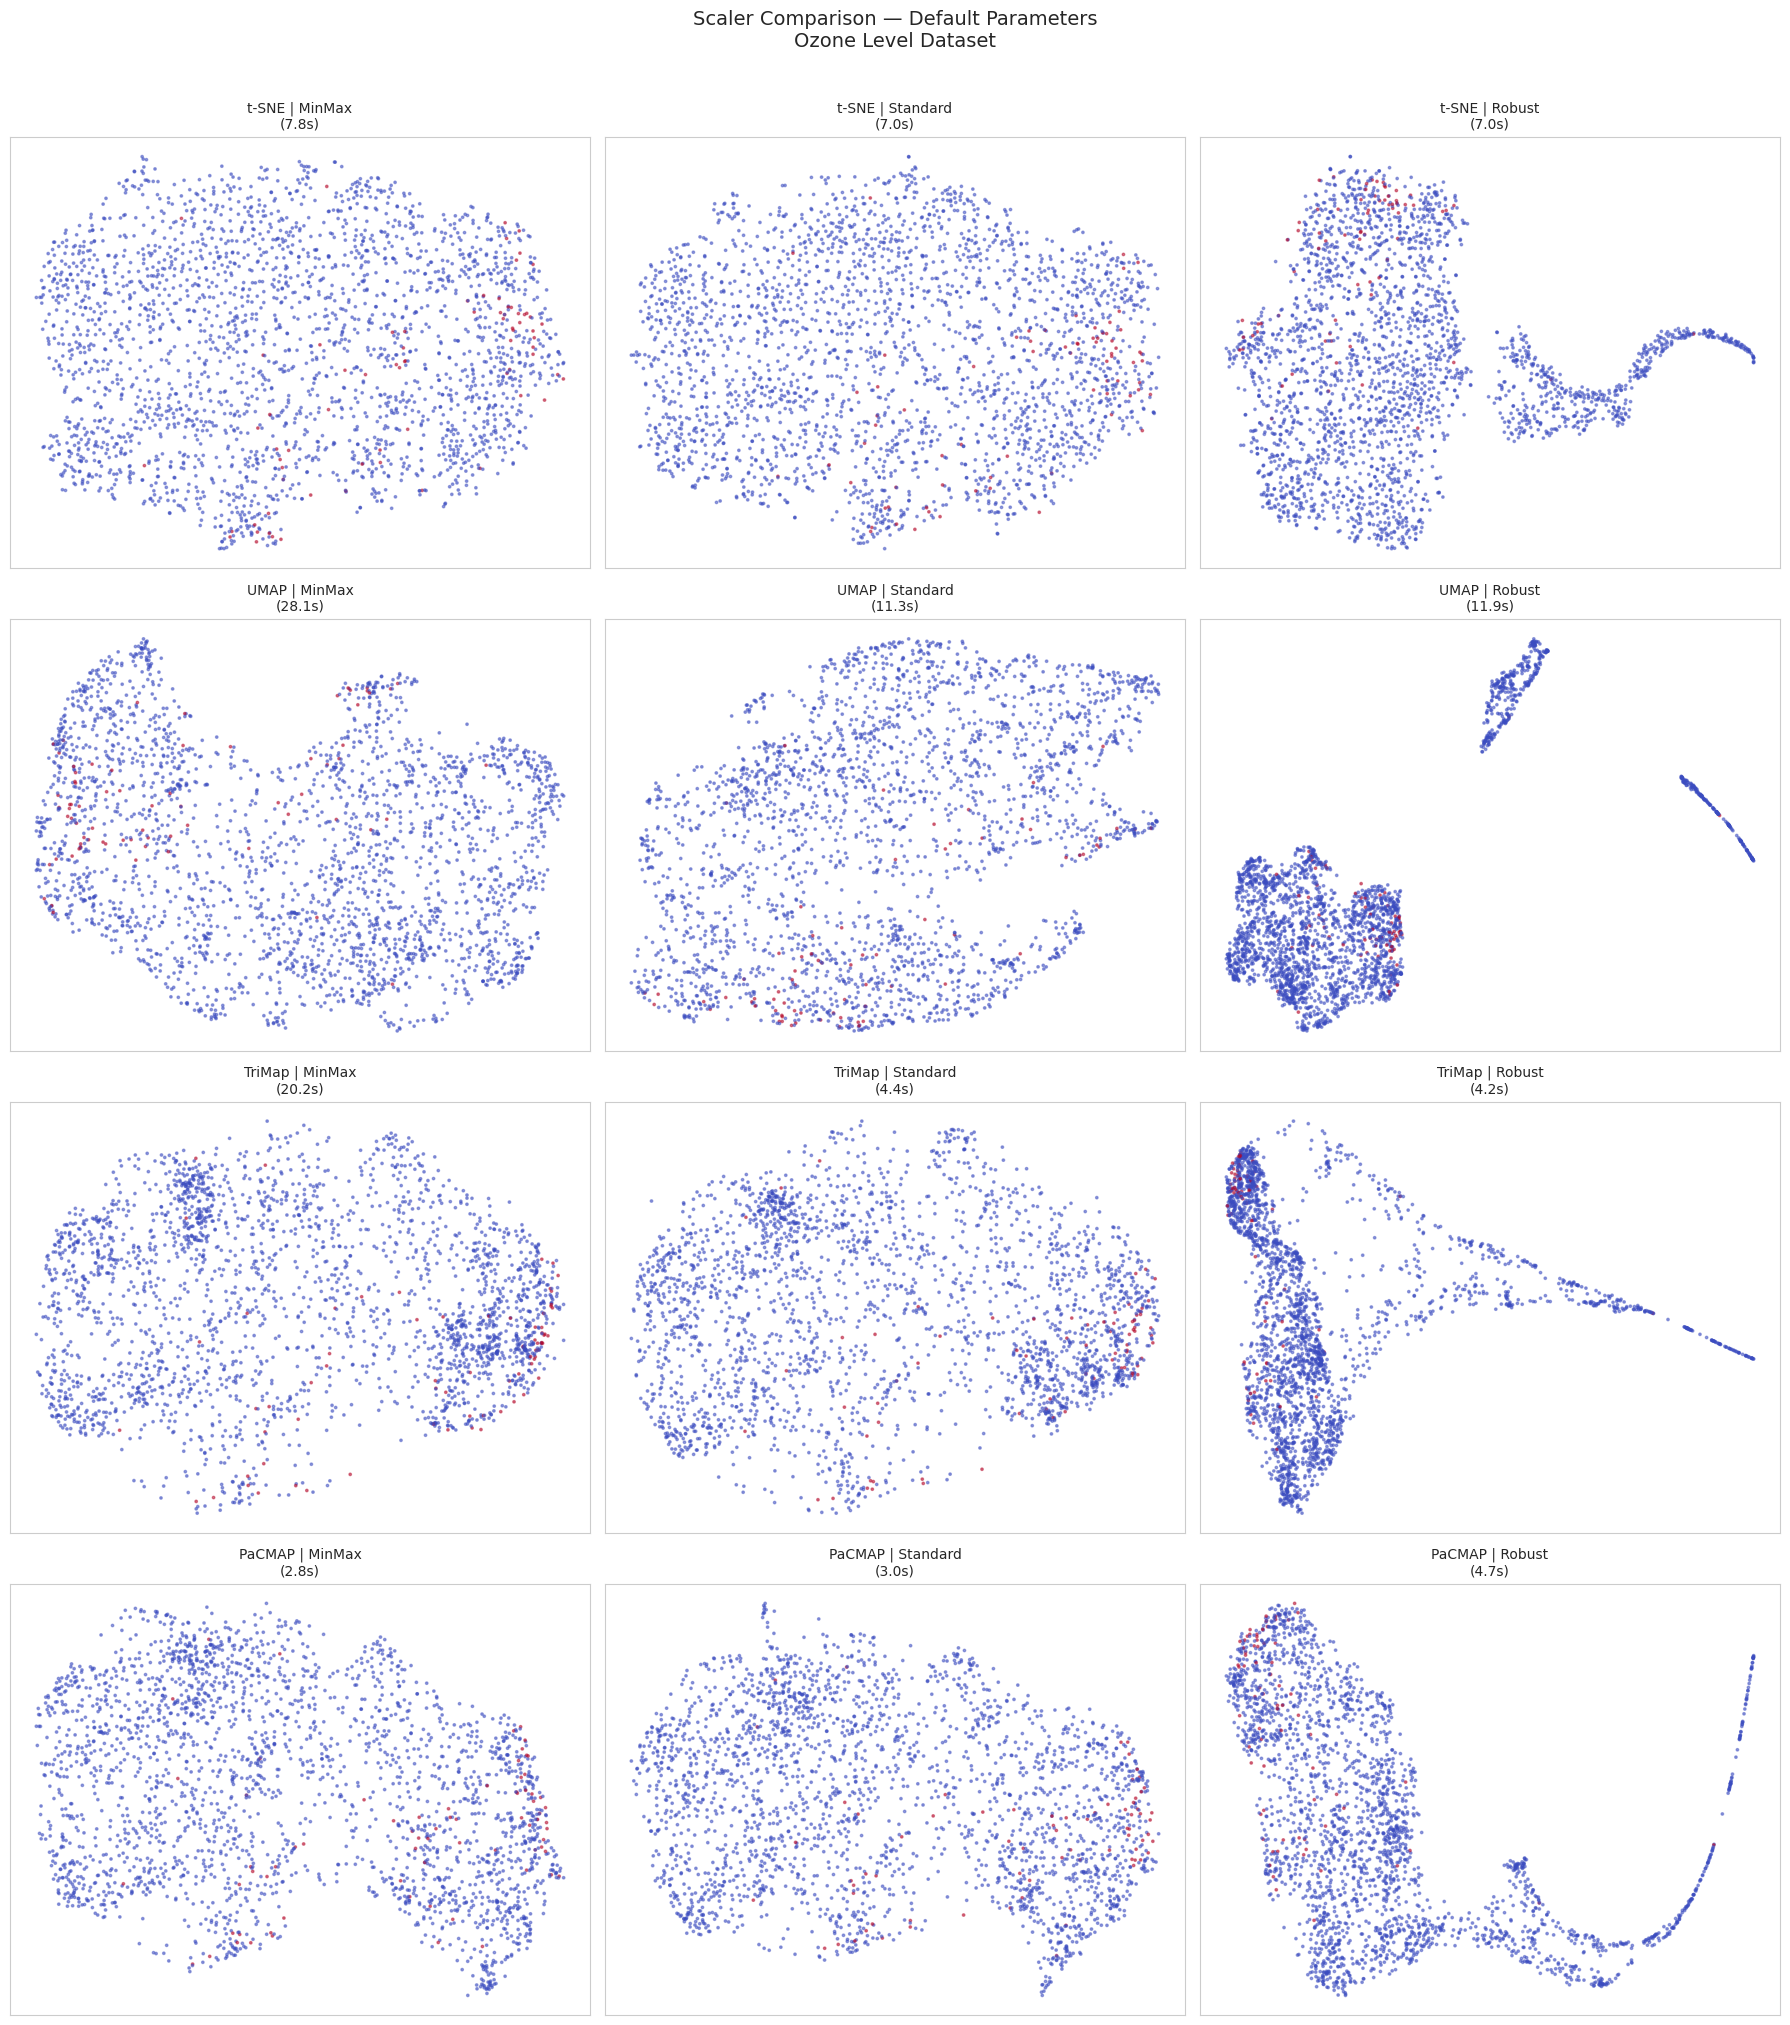

In [8]:
# Compare the three scalers for each algorithm using DEFAULT parameters
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle('Scaler Comparison — Default Parameters\nOzone Level Dataset',
             fontsize=14, y=1.01)

scaler_names = ['MinMax', 'Standard', 'Robust']

for row, (algo_name, params_list) in enumerate(algo_configs):
    default_params = params_list[0]  # First is default
    label = default_params[0]  # 'Default'
    
    for col, scaler_name in enumerate(scaler_names):
        key = f"{scaler_name}_{algo_name}_{label}"
        ax = axes[row, col]
        
        res = results.get(key)
        if res and res['embedding'] is not None:
            X_2d = res['embedding']
            ax.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=y, cmap='coolwarm', s=3, alpha=0.5)
            ax.set_title(f'{algo_name} | {scaler_name}\n({res["time"]:.1f}s)',
                        fontsize=10)
        else:
            ax.set_title(f'{algo_name} | {scaler_name}\n(FAILED)', fontsize=10)
            ax.text(0.5, 0.5, 'Error', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='red')
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('ozone_level_scaler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Timing Comparison Diagram

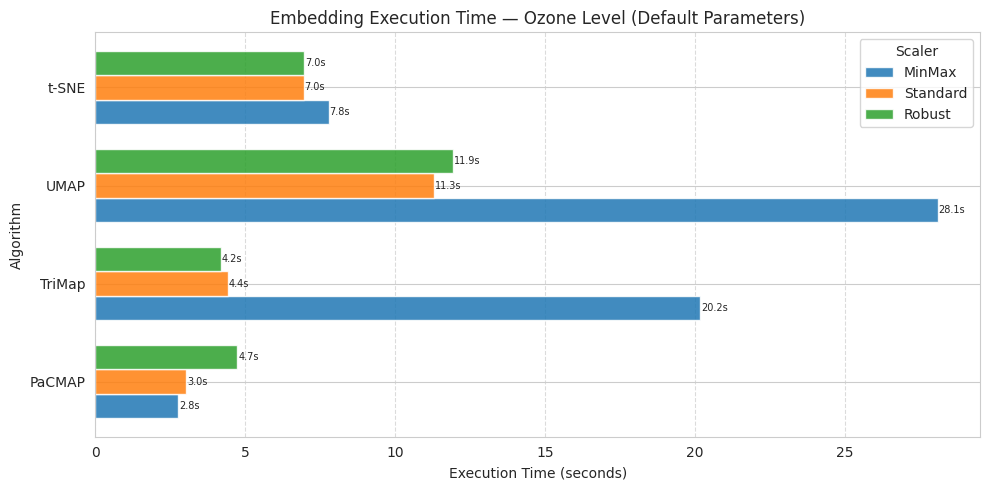


Timing summary (seconds):
Scaler     MinMax  Robust  Standard
Algorithm                          
PaCMAP       2.77    4.74      3.04
TriMap      20.19    4.19      4.44
UMAP        28.12   11.94     11.31
t-SNE        7.79    6.98      6.96


In [9]:
# Collect timing data for default parameters
timing_data = []

for algo_name, params_list in algo_configs:
    default_label = params_list[0][0]
    for scaler_name in scaler_names:
        key = f"{scaler_name}_{algo_name}_{default_label}"
        res = results.get(key)
        if res and res['time'] is not None:
            timing_data.append({
                'Algorithm': algo_name,
                'Scaler': scaler_name,
                'Time (s)': res['time']
            })

timing_df = pd.DataFrame(timing_data)

# Pivot for grouped horizontal bar chart
pivot_df = timing_df.pivot(index='Algorithm', columns='Scaler', values='Time (s)')

fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(pivot_df.index))
bar_height = 0.25

for i, scaler in enumerate(scaler_names):
    values = pivot_df[scaler].values
    ax.barh(y_pos + i * bar_height, values, bar_height,
            label=scaler, alpha=0.85)

ax.set_yticks(y_pos + bar_height)
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('Execution Time (seconds)')  # TIME ON X-AXIS
ax.set_ylabel('Algorithm')
ax.set_title('Embedding Execution Time — Ozone Level (Default Parameters)')
ax.legend(title='Scaler')
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Annotate values
for i, scaler in enumerate(scaler_names):
    for j, val in enumerate(pivot_df[scaler].values):
        ax.text(val + 0.02, y_pos[j] + i * bar_height,
                f'{val:.1f}s', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('ozone_level_timing.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTiming summary (seconds):")
print(pivot_df.round(2))

### Part Two: 3D Object Embedding

In [10]:
# Load mammoth.csv
mammoth = pd.read_csv('mammoth.csv')

print(f"Mammoth dataset shape: {mammoth.shape}")
print(f"Columns: {mammoth.columns.tolist()}")
print(f"Data types:\n{mammoth.dtypes}")
print(f"\nFirst 5 rows:\n{mammoth.head()}")

# Extract features
X_mam_full = mammoth[['x', 'y', 'z']].values

# Subsample for computational feasibility
# t-SNE on 1M points would take hours
n_samples = 3000
idx = np.random.choice(len(X_mam_full), n_samples, replace=False)
X_mam = X_mam_full[idx]

print(f"\nSubsampled mammoth: {X_mam.shape}")
print(f"(Original had {len(X_mam_full):,} points)")

Mammoth dataset shape: (999778, 3)
Columns: ['x', 'y', 'z']
Data types:
x    float64
y    float64
z    float64
dtype: object

First 5 rows:
        x        y       z
0  58.823  228.407  79.843
1  59.197  228.642  77.478
2  58.734  228.931  78.515
3  59.043  228.693  78.571
4  59.223  228.667  78.611

Subsampled mammoth: (3000, 3)
(Original had 999,778 points)


### Apply scaling to mammoth

In [11]:
# Scale mammoth data
X_mam_scaled = {}
for name, scaler in scalers.items():
    X_mam_scaled[name] = scaler.fit_transform(X_mam)
    print(f"{name} scaling complete — shape: {X_mam_scaled[name].shape}")

# Show effect
print("\n--- Mammoth scaling comparison ---")
for name, X_s in X_mam_scaled.items():
    print(f"\n{name}:")
    print(f"  Mean: {X_s.mean(axis=0).round(4)}")
    print(f"  Std:  {X_s.std(axis=0).round(4)}")

MinMax scaling complete — shape: (3000, 3)
Standard scaling complete — shape: (3000, 3)
Robust scaling complete — shape: (3000, 3)

--- Mammoth scaling comparison ---

MinMax:
  Mean: [0.5084 0.5757 0.6299]
  Std:  [0.1758 0.2093 0.2652]

Standard:
  Mean: [0. 0. 0.]
  Std:  [1. 1. 1.]

Robust:
  Mean: [-0.0106  0.1186 -0.3587]
  Std:  [0.6484 0.715  0.9207]


### Run embeddings on mammoth

In [12]:
# Store mammoth results
mam_results = {}

# Run all combinations (using same parameter lists)
for scaler_name, X_s in X_mam_scaled.items():
    print(f"\n{'='*60}")
    print(f"MAMMOTH — SCALER: {scaler_name}")
    print(f"{'='*60}")
    
    for algo_name, params_list in algo_configs:
        for params in params_list:
            label = params[0]
            key = f"{scaler_name}_{algo_name}_{label}"
            
            X_2d, elapsed, error = run_embedding(algo_name, X_s, params)
            
            if error:
                print(f"  ✗ {algo_name} [{label}]: FAILED — {error}")
                mam_results[key] = {'embedding': None, 'time': elapsed, 'error': error}
            else:
                print(f"  ✓ {algo_name} [{label}]: {elapsed:.2f}s")
                mam_results[key] = {'embedding': X_2d, 'time': elapsed, 'error': None}

print(f"\n{'='*60}")
print(f"Total mammoth embeddings: {sum(1 for v in mam_results.values() if v['embedding'] is not None)}")


MAMMOTH — SCALER: MinMax
  ✓ t-SNE [Default]: 7.55s
  ✓ t-SNE [P5]: 5.62s
  ✓ t-SNE [P15]: 5.54s
  ✓ t-SNE [P50]: 7.43s
  ✓ t-SNE [P30-EE24-LR500-N2000]: 13.32s
  ✓ t-SNE [P100]: 10.86s
  ✓ t-SNE [P15-EE8-LR200-N500]: 3.10s
  ✓ UMAP [Default]: 14.70s
  ✓ UMAP [N5]: 13.64s
  ✓ UMAP [N30]: 17.09s
  ✓ UMAP [N50-MD0]: 19.36s
  ✓ UMAP [N15-MD0.5-MAN]: 15.52s
  ✓ UMAP [N100-MD0.99-COS]: 19.28s
  ✓ UMAP [N10-MD0.01]: 12.86s
  ✓ TriMap [Default]: 4.96s
  ✓ TriMap [IN5-OUT3-RND3]: 2.99s
  ✓ TriMap [IN20-OUT10-RND10]: 12.43s
  ✓ TriMap [IN50-OUT20-RND20-N800]: 99.94s
  ✓ TriMap [IN10-OUT10-RND5-N200]: 4.46s
  ✓ TriMap [IN20-OUT5-RND20-N800]: 14.53s


  ✓ TriMap [IN15-OUT8-RND8]: 8.40s


  ✓ PaCMAP [Default]: 2.88s


  ✓ PaCMAP [N5]: 1.21s


  ✓ PaCMAP [N20]: 3.79s


...

  ✓ PaCMAP [N5]: 1.93s


  ✓ PaCMAP [N20]: 3.77s


  ✓ PaCMAP [N50-MN1.0]: 9.70s


  ✓ PaCMAP [N10-MN0.1-FP5.0]: 4.58s


  ✓ PaCMAP [N10-MN2.0-FP0.5]: 3.44s
  ✓ PaCMAP [N15-MN0.8-FP1.5]: 3.05s

Total mammoth embeddings: 84


### Visualize mammoth embeddings

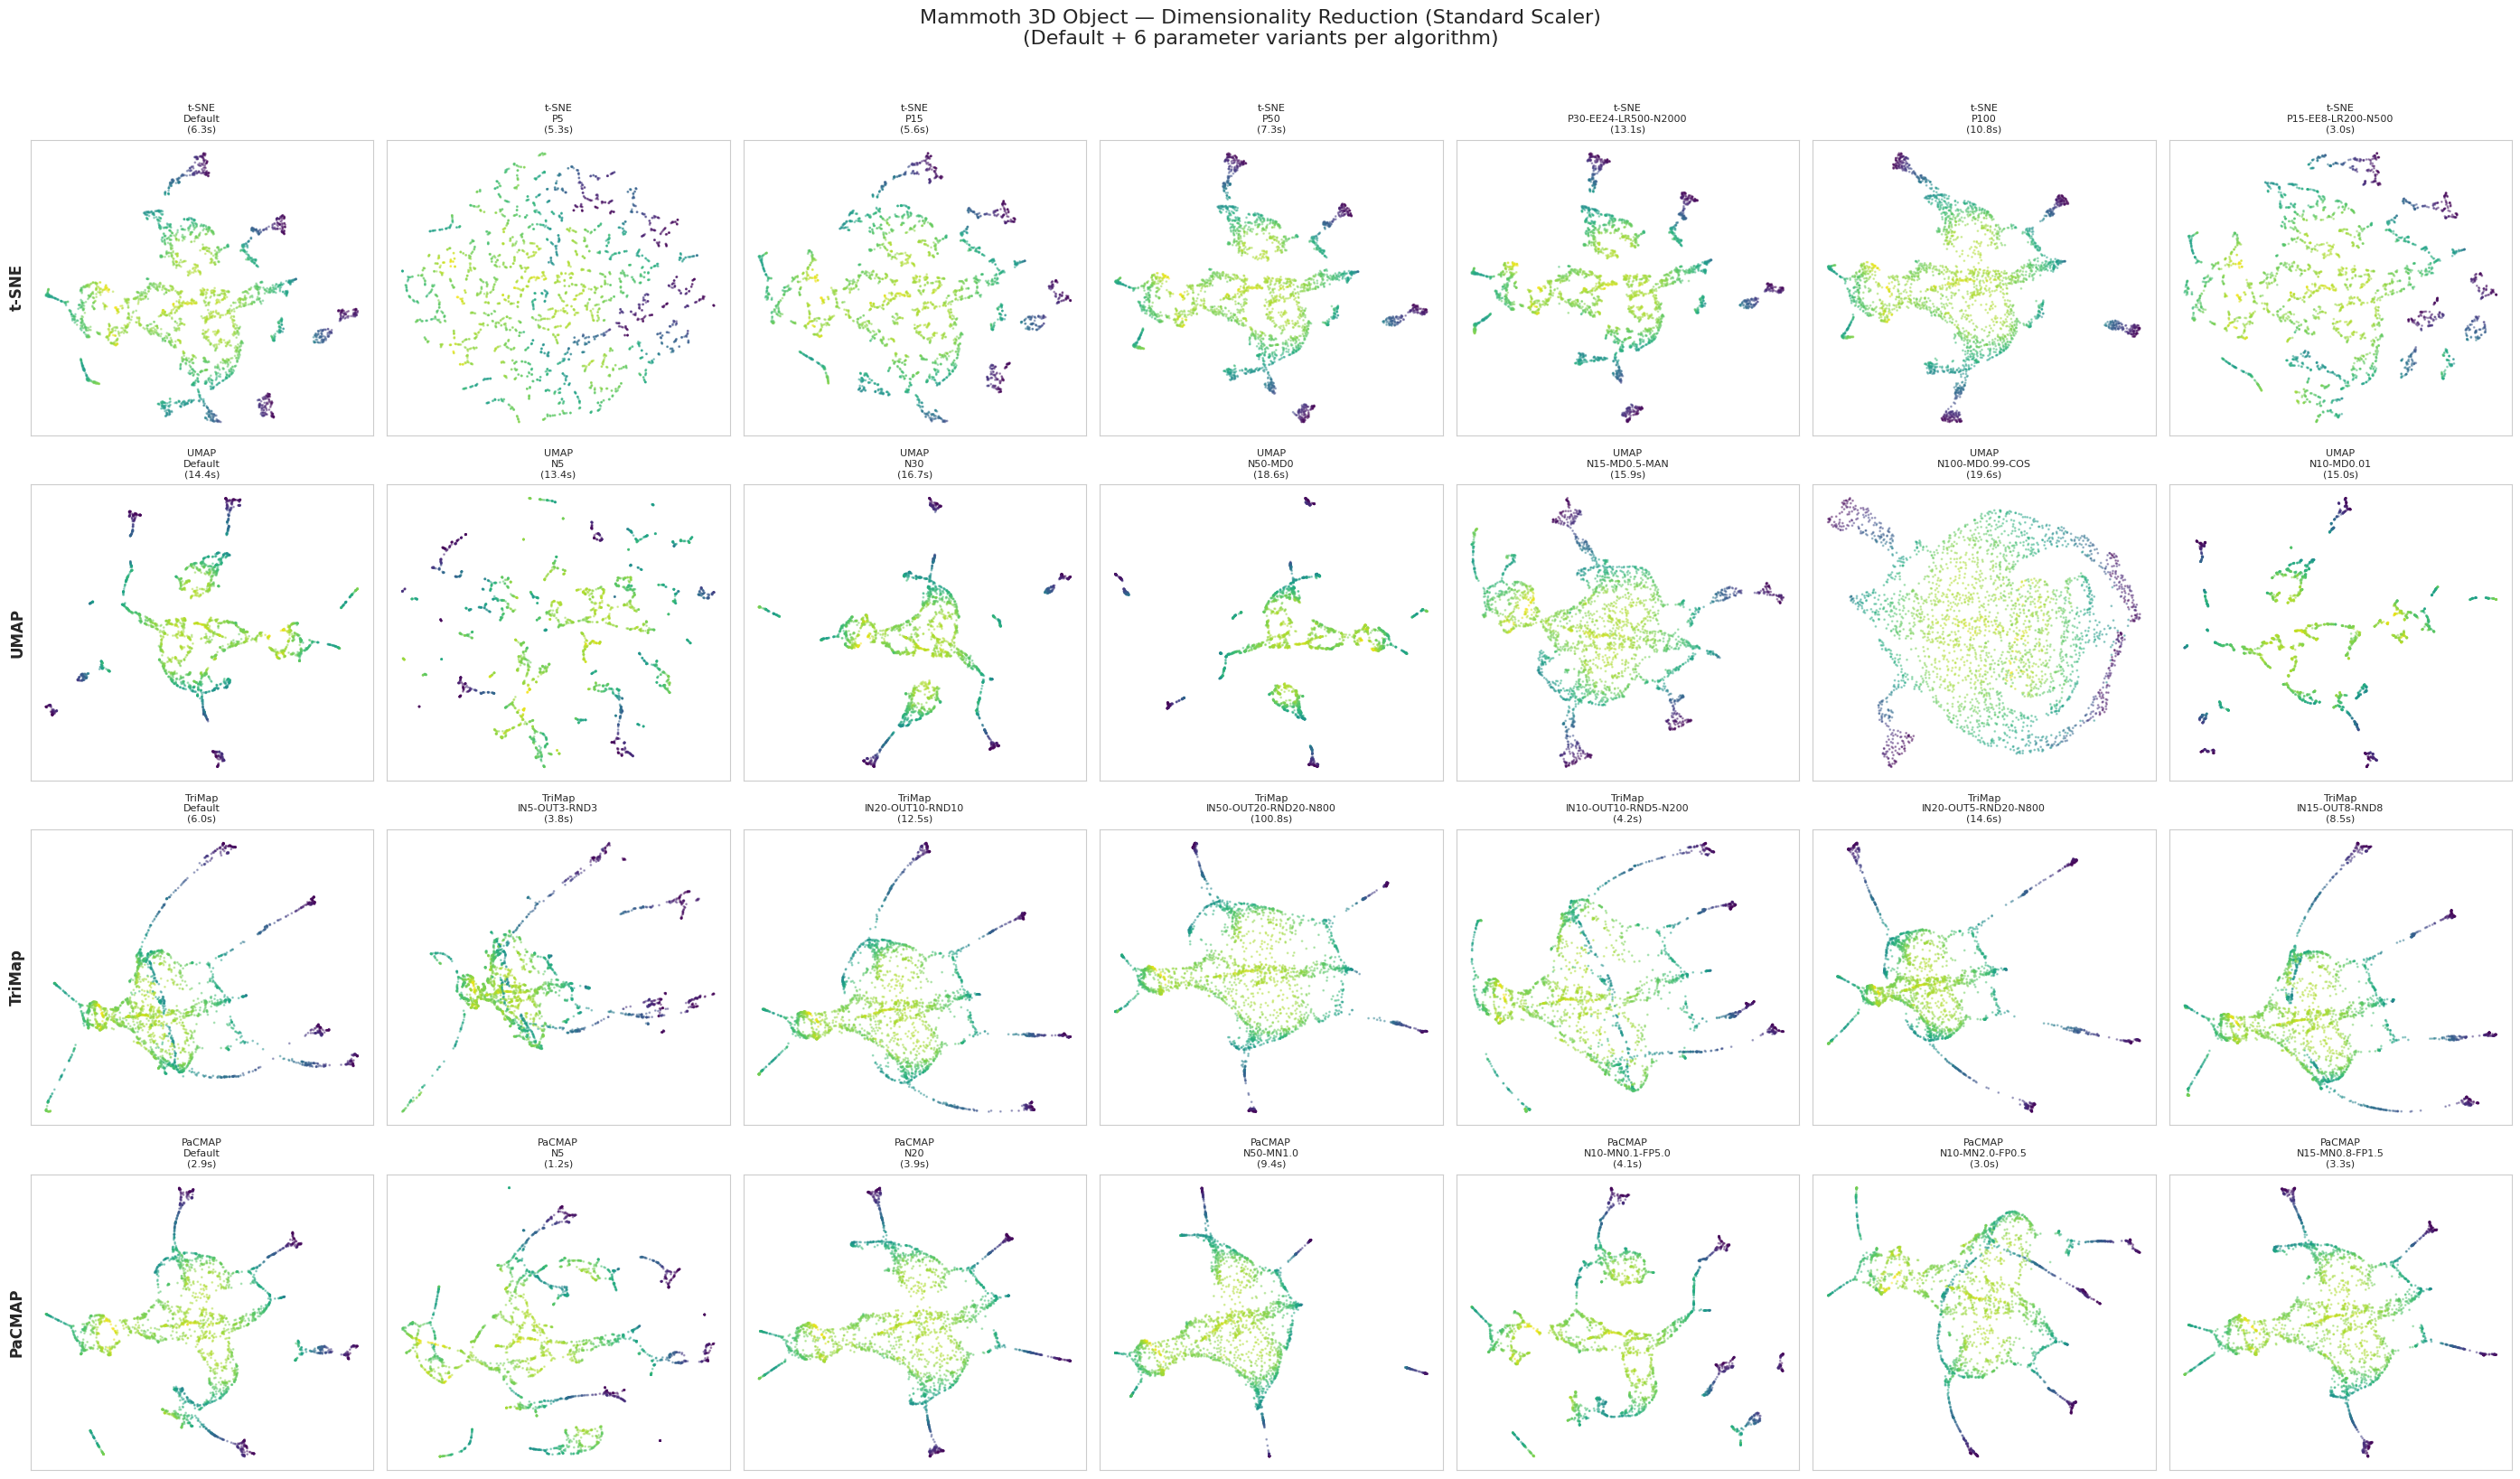

In [13]:
fig, axes = plt.subplots(4, 7, figsize=(28, 16))
fig.suptitle('Mammoth 3D Object — Dimensionality Reduction (Standard Scaler)\n(Default + 6 parameter variants per algorithm)',
             fontsize=16, y=1.02)

for row, (algo_name, params_list) in enumerate(algo_configs):
    for col, params in enumerate(params_list):
        label = params[0]
        key = f"Standard_{algo_name}_{label}"
        
        ax = axes[row, col]
        res = mam_results.get(key)
        
        if res and res['embedding'] is not None:
            X_2d = res['embedding']
            ax.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=X_mam[:, 2], cmap='viridis', s=1, alpha=0.4)
            ax.set_title(f'{algo_name}\n{label}\n({res["time"]:.1f}s)',
                        fontsize=8)
        else:
            ax.set_title(f'{algo_name}\n{label}\n(FAILED)', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

for row, (algo_name, _) in enumerate(algo_configs):
    axes[row, 0].set_ylabel(algo_name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('mammoth_Standard_scaler.png', dpi=150, bbox_inches='tight')
plt.show()

### Scaler comparison for mammoth

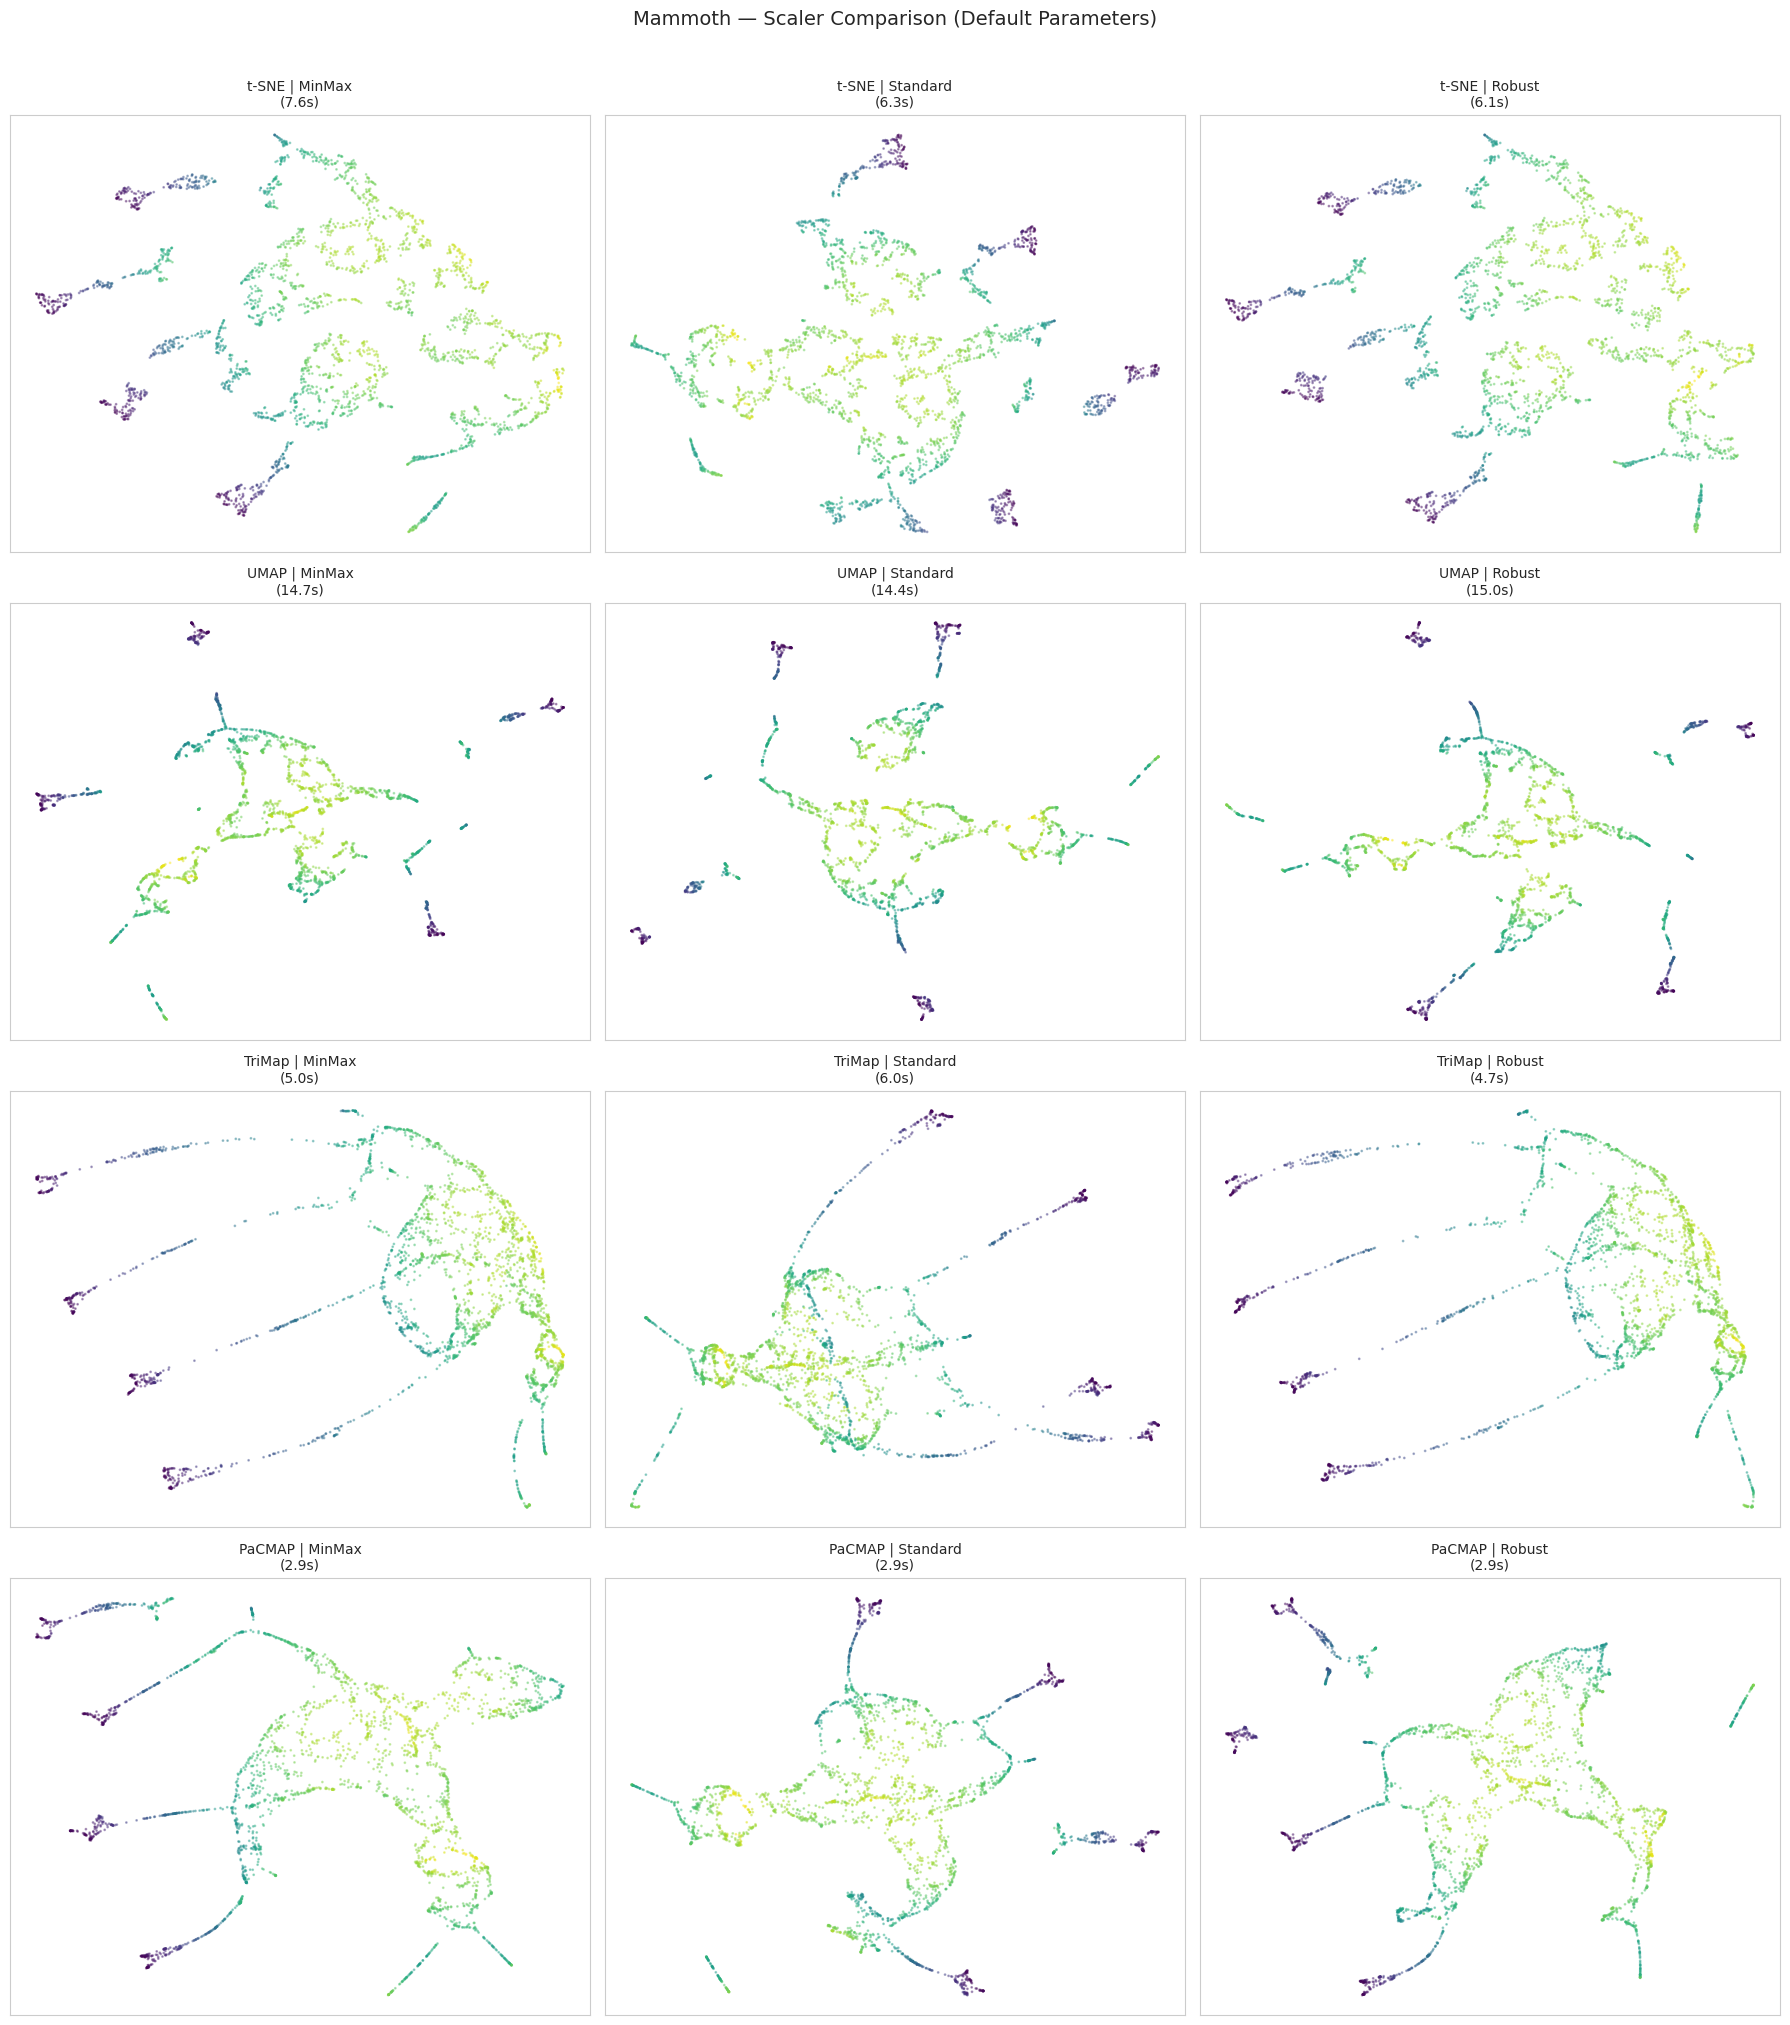

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle('Mammoth — Scaler Comparison (Default Parameters)',
             fontsize=14, y=1.01)

for row, (algo_name, params_list) in enumerate(algo_configs):
    default_label = params_list[0][0]
    
    for col, scaler_name in enumerate(scaler_names):
        key = f"{scaler_name}_{algo_name}_{default_label}"
        ax = axes[row, col]
        
        res = mam_results.get(key)
        if res and res['embedding'] is not None:
            X_2d = res['embedding']
            ax.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=X_mam[:, 2], cmap='viridis', s=1, alpha=0.4)
            ax.set_title(f'{algo_name} | {scaler_name}\n({res["time"]:.1f}s)',
                        fontsize=10)
        else:
            ax.set_title(f'{algo_name} | {scaler_name}\n(FAILED)', fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('mammoth_scaler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Timing comparison

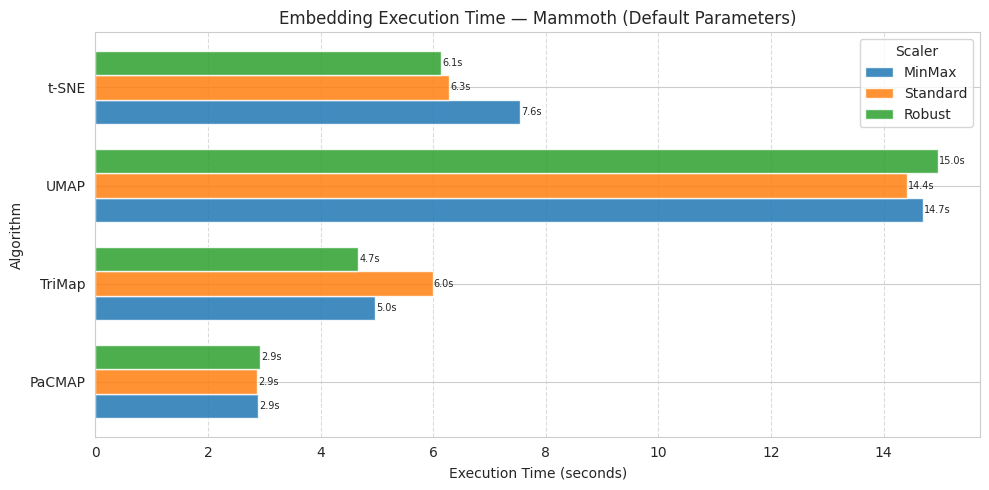


Mammoth timing summary (seconds):
Scaler     MinMax  Robust  Standard
Algorithm                          
PaCMAP       2.88    2.93      2.87
TriMap       4.96    4.67      5.99
UMAP        14.70   14.96     14.41
t-SNE        7.55    6.14      6.28


In [15]:
# Collect mammoth timing data
mam_timing = []

for algo_name, params_list in algo_configs:
    default_label = params_list[0][0]
    for scaler_name in scaler_names:
        key = f"{scaler_name}_{algo_name}_{default_label}"
        res = mam_results.get(key)
        if res and res['time'] is not None:
            mam_timing.append({
                'Algorithm': algo_name,
                'Scaler': scaler_name,
                'Time (s)': res['time']
            })

mam_timing_df = pd.DataFrame(mam_timing)
mam_pivot = mam_timing_df.pivot(index='Algorithm', columns='Scaler', values='Time (s)')

fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(mam_pivot.index))
bar_height = 0.25

for i, scaler in enumerate(scaler_names):
    values = mam_pivot[scaler].values
    ax.barh(y_pos + i * bar_height, values, bar_height,
            label=scaler, alpha=0.85)

ax.set_yticks(y_pos + bar_height)
ax.set_yticklabels(mam_pivot.index)
ax.set_xlabel('Execution Time (seconds)')  # TIME ON X-AXIS
ax.set_ylabel('Algorithm')
ax.set_title('Embedding Execution Time — Mammoth (Default Parameters)')
ax.legend(title='Scaler')
ax.grid(axis='x', linestyle='--', alpha=0.7)

for i, scaler in enumerate(scaler_names):
    for j, val in enumerate(mam_pivot[scaler].values):
        ax.text(val + 0.02, y_pos[j] + i * bar_height,
                f'{val:.1f}s', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('mammoth_timing.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMammoth timing summary (seconds):")
print(mam_pivot.round(2))